In [13]:
import pandas as pd
import numpy as np
import torch

In [14]:
# Cell 3: ConditionalVAE (loss_function MODIFIED)
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Tuple

class ConditionalVAE(nn.Module):
    def __init__(self,
                 in_channels: int = 1,
                 loc_channels: int = 2,
                 mask_channels: int = 1,
                 latent_dim: int = 16,
                 hidden_dims: List[int] = [32, 64, 128, 256, 512],
                 img_size: int = 40):
        super().__init__()

        self.latent_dim = latent_dim
        self.img_size = img_size
        self.in_channels = in_channels
        self.loc_channels = loc_channels
        self.mask_channels = mask_channels

        # ---------------- Encoder ----------------
        enc_in_channels = in_channels + loc_channels + mask_channels
        self.hidden_dims_enc = hidden_dims
        modules = []
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(enc_in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU()
                )
            )
            enc_in_channels = h_dim
        self.encoder = nn.Sequential(*modules)

        # Compute encoder output sizes dynamically
        encoder_sizes = self.compute_encoder_sizes(img_size, hidden_dims)
        self.final_spatial = encoder_sizes[-1]
        flat_size = hidden_dims[-1] * self.final_spatial**2

        # Latent space
        self.fc_mu = nn.Linear(flat_size, latent_dim)
        self.fc_var = nn.Linear(flat_size, latent_dim)

        # ---------------- Decoder ----------------
        self.decoder_input = nn.Linear(
            latent_dim + (loc_channels + mask_channels) * img_size * img_size,
            flat_size
        )

        self.hidden_dims_dec = hidden_dims[::-1]

        dec_modules = []
        for i in range(len(self.hidden_dims_dec) - 1):
            dec_modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        self.hidden_dims_dec[i],
                        self.hidden_dims_dec[i+1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=0  # always 0, we will pad later
                    ),
                    nn.BatchNorm2d(self.hidden_dims_dec[i+1]),
                    nn.LeakyReLU()
                )
            )
        self.decoder = nn.Sequential(*dec_modules)

        self.final_mu = nn.Conv2d(self.hidden_dims_dec[-1], out_channels=in_channels, kernel_size=3, padding=1)
        self.final_logvar = nn.Conv2d(self.hidden_dims_dec[-1], out_channels=in_channels, kernel_size=3, padding=1)

    # ---------------- Static methods ----------------
    @staticmethod
    def compute_encoder_sizes(img_size, hidden_dims, kernel_size=3, stride=2, padding=1):
        sizes = []
        size = img_size
        for _ in hidden_dims:
            size = (size + 2*padding - kernel_size) // stride + 1
            sizes.append(size)
        return sizes

    # ---------------- Forward methods ----------------
    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        result = self.encoder(x)
        result = torch.flatten(result, start_dim=1)
        mu = self.fc_mu(result)
        log_var = self.fc_var(result)
        return mu, log_var

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps * std + mu

    def decode(self, z: torch.Tensor, loc_mask: torch.Tensor, meas_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # Combine conditioning info
        cond = torch.cat([loc_mask, meas_mask], dim=1)
        cond_flat = cond.view(cond.size(0), -1)
        dec_input = torch.cat([z, cond_flat], dim=1)

        result = self.decoder_input(dec_input)
        result = result.view(-1, self.hidden_dims_dec[0], self.final_spatial, self.final_spatial)
        result = self.decoder(result)

        # Zero-pad to ensure output is img_size x img_size
        _, _, h, w = result.shape
        pad_h = self.img_size - h
        pad_w = self.img_size - w
        if pad_h > 0 or pad_w > 0:
            # pad = (left, right, top, bottom)
            result = F.pad(result, (0, pad_w, 0, pad_h))

        mu_pred = self.final_mu(result)
        logvar_pred = torch.clamp(self.final_logvar(result), -10, 10)
        return mu_pred, logvar_pred

    def forward(self, x: torch.Tensor, loc_mask: torch.Tensor, meas_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        # Tile location mask if needed
        if loc_mask.dim() == 3:
            loc_mask = loc_mask.unsqueeze(0).repeat(x.size(0), 1, 1, 1)

        enc_in = torch.cat([x, loc_mask, meas_mask], dim=1)
        mu, log_var = self.encode(enc_in)
        z = self.reparameterize(mu, log_var)
        mu_pred, logvar_pred = self.decode(z, loc_mask, meas_mask)
        return mu_pred, logvar_pred, mu, log_var

    # ---------------- Loss function ----------------
    # --- MODIFIED to accept valid_mask ---
    def loss_function(self, x: torch.Tensor, mu_pred: torch.Tensor, logvar_pred: torch.Tensor,
                      mu: torch.Tensor, log_var: torch.Tensor, valid_mask: torch.Tensor, 
                      kld_weight: float = 1e-3) -> dict:
        
        const = torch.log(torch.tensor(2.0 * torch.pi, device=x.device))
        recon_var = torch.exp(logvar_pred)
        nll_element = 0.5 * ((x - mu_pred)**2 / recon_var + logvar_pred + const)

        # --- MODIFICATION: Apply valid_mask ---
        # valid_mask is [1, 1, H, W], nll_element is [B, 1, H, W]
        # Broadcasting will apply the mask to every sample in the batch
        nll_element_masked = nll_element * valid_mask
        
        # Get total NLL sum over all valid pixels in the batch
        total_nll_sum = torch.sum(nll_element_masked)
        
        # Get total number of valid pixels in the batch
        num_valid_per_sample = torch.sum(valid_mask)
        batch_size = x.size(0)
        total_valid_count = num_valid_per_sample * batch_size

        # Calculate mean NLL, handling potential division by zero
        if total_valid_count > 0:
            nll_loss = total_nll_sum / total_valid_count
        else:
            # If no valid pixels, set NLL loss to 0
            nll_loss = torch.tensor(0.0, device=x.device, requires_grad=True)
        # --- End MODIFICATION ---

        kld_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1))
        total_loss = nll_loss + kld_weight * kld_loss
        return {"loss": total_loss, "NLL": nll_loss, "KLD": kld_loss}

In [15]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim import Adam
from tqdm import tqdm

# -----------------------------
# 1️⃣ Load CSVs
# -----------------------------
df_coords = pd.read_csv("original_1600_grid_points.csv")
df_valid = pd.read_csv("inside.csv", header=None, names=['X','Y'])
df_measurements = pd.read_csv("combined_sinr.csv")  # 30 × 7700

H, W = 40, 40

# -----------------------------
# 2️⃣ Coordinates → Grid Indices
# -----------------------------
def coords_to_indices(df, H, W):
    x_vals = df['X'].values
    y_vals = df['Y'].values

    x_norm = (x_vals - x_vals.min()) / (x_vals.max() - x_vals.min())
    y_norm = (y_vals - y_vals.min()) / (y_vals.max() - y_vals.min())

    x_idx = np.clip((x_norm * (W-1)).astype(int), 0, W-1)
    y_idx = np.clip((y_norm * (H-1)).astype(int), 0, H-1)

    return np.stack([y_idx, x_idx], axis=1)

# Valid region mask
valid_indices = coords_to_indices(df_valid, H, W)

# Sensor measurement points (30 sensors)
measurement_indices = coords_to_indices(df_measurements[['X','Y']], H, W)
measurement_indices = np.array(measurement_indices)

# -----------------------------
# 3️⃣ Create Valid Mask
# -----------------------------
valid_mask = torch.zeros((H, W), dtype=torch.bool)
valid_mask[valid_indices[:,0], valid_indices[:,1]] = True
valid_coords_mask = valid_mask.unsqueeze(0).unsqueeze(0).float()  # (1,1,H,W)

# -----------------------------
# 4️⃣ Extract SINR samples (30 × 7700)
# -----------------------------
data_array = df_measurements.iloc[:, 2:].values.astype(np.float32)
num_sensors, num_samples = data_array.shape

# -----------------------------
# 5️⃣ ⭐ STANDARDIZE (per sensor)
# -----------------------------
means = data_array.mean(axis=1, keepdims=True)
stds = data_array.std(axis=1, keepdims=True) + 1e-8

data_array_std = (data_array - means) / stds

# -----------------------------
# 6️⃣ Fill the (samples, 40, 40) grid
# -----------------------------
grid = np.zeros((num_samples, H, W), dtype=np.float32)

for idx, (r, c) in enumerate(measurement_indices):
    grid[:, r, c] = data_array_std[idx]

# Final X_data shape = (7700, 1, 40, 40)
X_data = torch.tensor(grid).unsqueeze(1).float()

print("Final X_data:", X_data.shape)

# -----------------------------
# 7️⃣ Validation coordinates
# -----------------------------
val_indices = [3, 6, 25, 12, 13, 17, 19, 21, 10, 2]

val_coords = measurement_indices[val_indices]
print("Validation coord grid positions:\n", val_coords)

val_coords_y = torch.tensor(val_coords[:, 0], dtype=torch.long)
val_coords_x = torch.tensor(val_coords[:, 1], dtype=torch.long)

# train coordinates = all except val set
train_mask = np.ones(len(measurement_indices), dtype=bool)
train_mask[val_indices] = False
train_coords = measurement_indices[train_mask]

train_coords_y = torch.tensor(train_coords[:, 0], dtype=torch.long)
train_coords_x = torch.tensor(train_coords[:, 1], dtype=torch.long)

num_train_locs = len(train_coords)
print("Train sensors:", num_train_locs)


Final X_data: torch.Size([7749, 1, 40, 40])
Validation coord grid positions:
 [[15  5]
 [29  7]
 [28 28]
 [14 12]
 [39 12]
 [14 19]
 [39 21]
 [20 23]
 [ 0 12]
 [13  3]]
Train sensors: 20


In [16]:
dataset = TensorDataset(X_data)

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=8, shuffle=False)


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConditionalVAE(
    in_channels=1,
    loc_channels=2,
    mask_channels=1,
    latent_dim=16,
    img_size=H,
    hidden_dims=[32,64,128,256,512]
).to(device)

optimizer = Adam(model.parameters(), lr=1e-3)
epochs = 50


In [18]:
# Build loc_mask_base (H × W × 2)
yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")

loc_x = (xx.float() / (W-1)).unsqueeze(0)  # (1,H,W)
loc_y = (yy.float() / (H-1)).unsqueeze(0)  # (1,H,W)

loc_mask_base = torch.cat([loc_x, loc_y], dim=0).unsqueeze(0)  # (1,2,H,W)


In [19]:
valid_coords_mask = valid_coords_mask.to(device)
loc_mask_base = loc_mask_base.to(device)
val_coords_y = val_coords_y.to(device)
val_coords_x = val_coords_x.to(device)
train_coords_y = train_coords_y.to(device)
train_coords_x = train_coords_x.to(device)

k_choices = torch.tensor([10, 15, 20, 25]).to(device)
k_probs   = torch.tensor([0.6, 0.133, 0.133, 0.133]).to(device)


In [20]:


def get_beta(epoch, max_epochs, warmup_epochs=10, final_beta=1.0):
    if epoch < warmup_epochs:
        return 0.0
    progress = (epoch - warmup_epochs) / (max_epochs - warmup_epochs)
    return min(final_beta, final_beta * progress)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    beta = get_beta(epoch, epochs)

    for (x_batch,) in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        x_batch = x_batch.to(device)
        B = x_batch.size(0)

        # 1. LOC mask
        loc_batch = loc_mask_base.repeat(B, 1, 1, 1)

        # 2. Random K sensors
        mask_batch = torch.zeros(B, 1, H, W, device=device)

        k_idx = torch.multinomial(k_probs, num_samples=B, replacement=True)
        k_vals = k_choices[k_idx]

        for i in range(B):
            k = k_vals[i].item()
            idx = torch.randperm(num_train_locs, device=device)[:k]
            y = train_coords_y[idx]
            x = train_coords_x[idx]
            mask_batch[i, 0, y, x] = 1.0

        # 3. Mask encoder input
        x_input = x_batch * mask_batch

        optimizer.zero_grad()

        mu_pred, logvar_pred, mu, log_var = model(x_input, loc_batch, mask_batch)

        losses = model.loss_function(
            x_batch, mu_pred, logvar_pred, mu, log_var,
            valid_mask=valid_coords_mask,
            kld_weight=beta
        )
        
        loss = losses["loss"]
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * B

    # ----------------------
    # VALIDATION
    # ----------------------
    model.eval()
    val_loss = 0.0

    # fixed 10-sensor mask
    val_mask = torch.zeros(1,1,H,W, device=device)
    val_mask[0,0,val_coords_y, val_coords_x] = 1.0

    with torch.no_grad():
        for (x_batch,) in val_loader:
            x_batch = x_batch.to(device)
            B = x_batch.size(0)

            loc_batch = loc_mask_base.repeat(B, 1, 1, 1)
            mask_batch = val_mask.repeat(B, 1, 1, 1)

            x_input = x_batch * mask_batch

            mu_pred, logvar_pred, mu, log_var = model(x_input, loc_batch, mask_batch)

            losses = model.loss_function(
                x_batch, mu_pred, logvar_pred, mu, log_var,
                valid_mask=valid_coords_mask,
                kld_weight=1e-3
            )

            val_loss += losses["loss"].item() * B

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}] | Train {train_loss:.4f} | Val {val_loss:.4f}")

print("Training complete!")
torch.save(model.state_dict(), "conditional_vae_model_2.pth")
print("Model saved to 'conditional_vae_model_2.pth'")


Epoch [1/50] | Train -0.1748 | Val 0.1195


Epoch [2/50] | Train -0.9112 | Val -0.7118


Epoch [3/50] | Train -1.1471 | Val -0.8198


Epoch [4/50] | Train -1.3625 | Val -1.2897


Epoch [5/50] | Train -1.5492 | Val -1.5096


...

Epoch [46/50] | Train -1.7686 | Val -1.7423


Epoch [47/50] | Train -1.7683 | Val -1.7422


Epoch [48/50] | Train -1.7685 | Val -1.7422


Epoch [49/50] | Train -1.7680 | Val -1.7425


Epoch [50/50] | Train -1.7683 | Val -1.7425
Training complete!
Model saved to 'conditional_vae_model_2.pth'


✅ Model loaded from 'conditional_vae_model_2.pth'


C:\Users\23917\AppData\Local\Temp\ipykernel_24708\3772779022.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("conditional_vae_model_2.p

✅ Loaded normalization parameters
Batch size: 8, Grid size: 40x40
x_input shape: torch.Size([8, 1, 40, 40])
Number of observed points per sample: 10.0
✅ Forward pass complete
Finding nearest sensors for each valid point...
✅ Found nearest sensors for 648 valid points
✅ Denormalization complete
✅ Grids constructed
Predicted grid shape: torch.Size([40, 40])
Ground truth grid shape: torch.Size([40, 40])
✅ Grids exported to TXT files:
  - pred_grid_output.txt
  - gt_grid_output.txt

📊 Evaluation Metrics (Original Scale):
MAE:  0.0359
RMSE: 0.0860
✅ Results saved to 'prediction_results.csv'
   Y   X  Nearest_Sensor  Predicted_SINR  Ground_Truth_SINR     Error
0  0  17              16       27.818405          27.813395  0.005011
1  1  14              10       27.570837          27.558266  0.012571
2  1  15              10       27.560545          27.558266  0.002279
3  1  16              16       27.817791          27.813395  0.004396
4  2  11              10       27.549805          27.5582

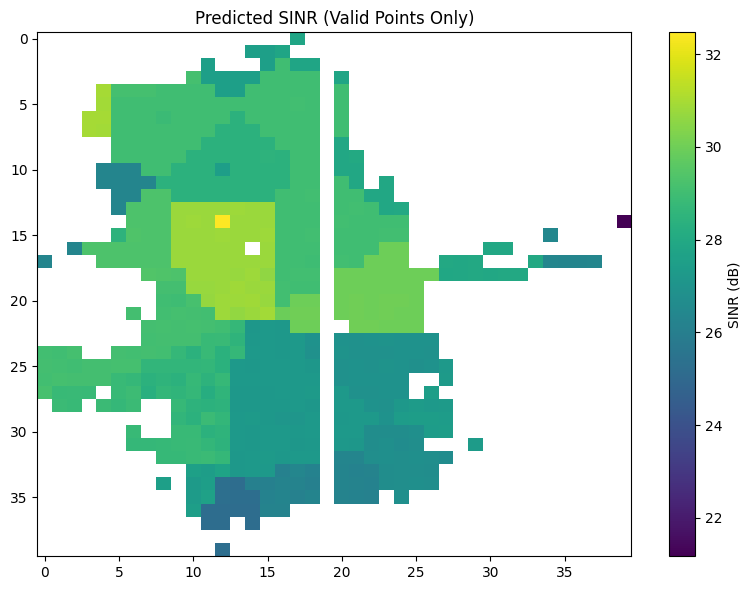

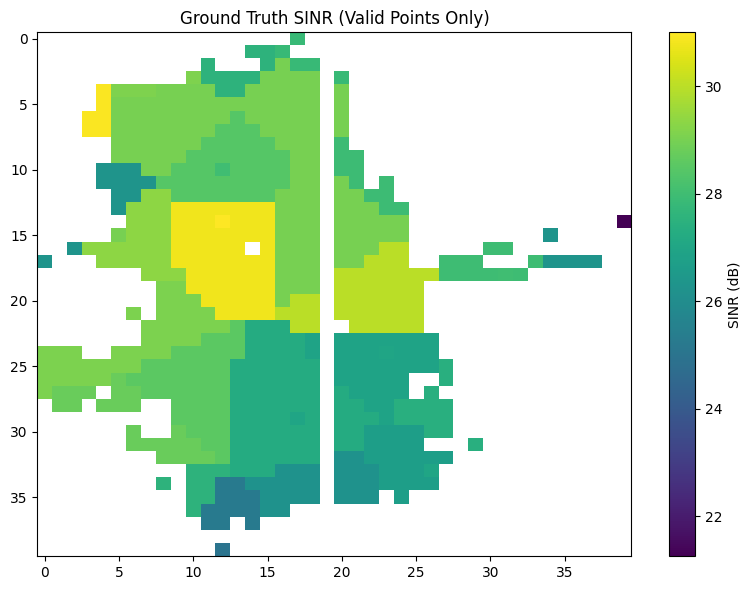

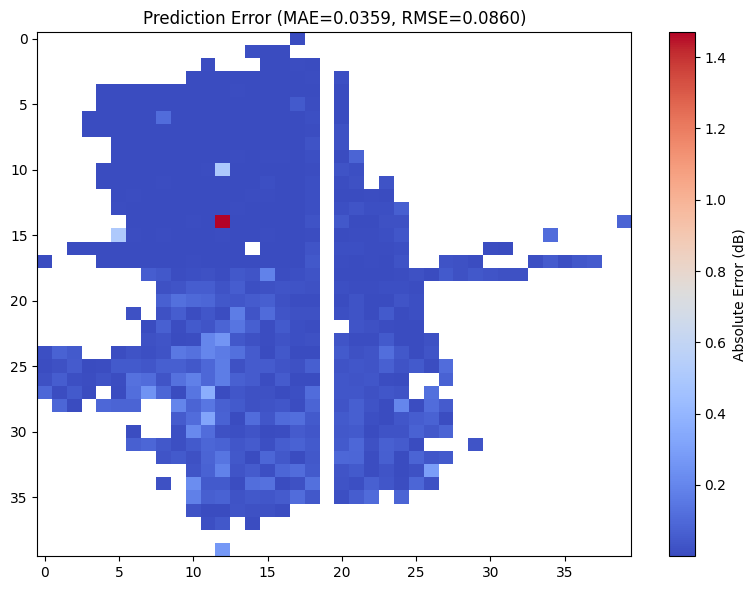


✅ All visualizations complete!
Files created:
  - prediction_results.csv
  - pred_grid.npy
  - gt_grid.npy
  - pred_grid_output.txt
  - gt_grid_output.txt
  - predicted_sinr.png
  - ground_truth_sinr.png
  - error_map.png


In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ✅ 第一步：加载训练好的模型
device = torch.device("cuda")

model = ConditionalVAE(
    in_channels=1,
    loc_channels=2,
    mask_channels=1,
    latent_dim=16,
    img_size=H,
    hidden_dims=[32,64,128,256,512]
).to(device)

model.load_state_dict(torch.load("conditional_vae_model_2.pth"))
print("✅ Model loaded from 'conditional_vae_model_2.pth'")

model.eval()

# ✅ 第二步：加载归一化参数
sensor_means = np.load("sensor_means.npy")  # (30, 1)
sensor_stds = np.load("sensor_stds.npy")    # (30, 1)
print("✅ Loaded normalization parameters")

# ✅ 第三步：获取验证数据
x_batch, = next(iter(val_loader))
x_batch = x_batch.to(device)
B = x_batch.size(0)

val_mask = torch.zeros(1, 1, H, W, device=device)
val_mask[0, 0, val_coords_y, val_coords_x] = 1.0
mask_batch = val_mask.expand(B, -1, -1, -1)
x_input = x_batch * mask_batch

print(f"Batch size: {B}, Grid size: {H}x{W}")
print("x_input shape:", x_input.shape)
print("Number of observed points per sample:", mask_batch[0].sum().item())

# ✅ 第四步：前向传播
with torch.no_grad():
    mu_pred, logvar_pred, _, _ = model(
        x_input, 
        loc_mask_base.repeat(B, 1, 1, 1), 
        mask_batch
    )
    std_pred = torch.exp(0.5 * logvar_pred)
    sampled_pred = mu_pred + std_pred * torch.randn_like(std_pred)

print("✅ Forward pass complete")

# ✅ 第五步：获取有效点索引
valid_y, valid_x = valid_mask.nonzero(as_tuple=True)
valid_y_cpu = valid_y.cpu().numpy()
valid_x_cpu = valid_x.cpu().numpy()

# ✅ 第六步：找到每个有效点最近的传感器
print("Finding nearest sensors for each valid point...")
sensor_indices = []
for y, x in zip(valid_y_cpu, valid_x_cpu):
    distances = np.sqrt((measurement_indices[:, 0] - y)**2 + 
                       (measurement_indices[:, 1] - x)**2)
    nearest_sensor = np.argmin(distances)
    sensor_indices.append(nearest_sensor)

sensor_indices = np.array(sensor_indices)
print(f"✅ Found nearest sensors for {len(sensor_indices)} valid points")

# ✅ 第七步：反归一化预测值
pred_vals_std = sampled_pred[0, 0, valid_y, valid_x].cpu().numpy()
pred_vals_orig = pred_vals_std * sensor_stds[sensor_indices, 0] + sensor_means[sensor_indices, 0]

# ✅ 第八步：反归一化真实值
gt_vals_std = x_batch[0, 0, valid_y_cpu, valid_x_cpu].cpu().numpy()
gt_vals_orig = gt_vals_std * sensor_stds[sensor_indices, 0] + sensor_means[sensor_indices, 0]

print("✅ Denormalization complete")

# ✅ 第九步：构建网格
pred_grid_orig = torch.zeros((H, W))
gt_grid_valid_only = torch.zeros((H, W))

pred_grid_orig[valid_y_cpu, valid_x_cpu] = torch.tensor(pred_vals_orig)
gt_grid_valid_only[valid_y_cpu, valid_x_cpu] = torch.tensor(gt_vals_orig)

print("✅ Grids constructed")
print("Predicted grid shape:", pred_grid_orig.shape)
print("Ground truth grid shape:", gt_grid_valid_only.shape)

# ✅ 输出网格到TXT文档
with open("pred_grid_output.txt", "w") as f:
    f.write("# Predicted SINR Grid (40x40)\n")
    f.write("# Format: Row-by-row, 0 indicates invalid/unobserved points\n\n")
    for i in range(H):
        row_values = [f"{pred_grid_orig[i, j].item():.6f}" for j in range(W)]
        f.write(" ".join(row_values) + "\n")

with open("gt_grid_output.txt", "w") as f:
    f.write("# Ground Truth SINR Grid (40x40)\n")
    f.write("# Format: Row-by-row, 0 indicates invalid/unobserved points\n\n")
    for i in range(H):
        row_values = [f"{gt_grid_valid_only[i, j].item():.6f}" for j in range(W)]
        f.write(" ".join(row_values) + "\n")

print("✅ Grids exported to TXT files:")
print("  - pred_grid_output.txt")
print("  - gt_grid_output.txt")

# ✅ 第十步：计算误差
error_vals = np.abs(pred_vals_orig - gt_vals_orig)
mae = error_vals.mean()
rmse = np.sqrt((error_vals ** 2).mean())

print(f"\n📊 Evaluation Metrics (Original Scale):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# ✅ 第十一步：导出结果为 CSV
df_results = pd.DataFrame({
    'Y': valid_y_cpu,
    'X': valid_x_cpu,
    'Nearest_Sensor': sensor_indices,
    'Predicted_SINR': pred_vals_orig,
    'Ground_Truth_SINR': gt_vals_orig,
    'Error': error_vals
})

df_results.to_csv("prediction_results.csv", index=False)
print("✅ Results saved to 'prediction_results.csv'")
print(df_results.head(10))

# ✅ 第十二步：保存网格
np.save("pred_grid.npy", pred_grid_orig.numpy())
np.save("gt_grid.npy", gt_grid_valid_only.numpy())
print("✅ Grids saved to 'pred_grid.npy' and 'gt_grid.npy'")

# ✅ 第十三步：可视化预测结果
masked_pred = np.ma.masked_where(pred_grid_orig == 0, pred_grid_orig)
plt.figure(figsize=(8, 6))
plt.imshow(masked_pred, cmap='viridis', aspect='auto')
plt.colorbar(label='SINR (dB)')
plt.title("Predicted SINR (Valid Points Only)")
plt.tight_layout()
plt.savefig("predicted_sinr.png", dpi=150)
plt.show()

# ✅ 第十四步：可视化真实值
masked_gt = np.ma.masked_where(gt_grid_valid_only == 0, gt_grid_valid_only)
plt.figure(figsize=(8, 6))
plt.imshow(masked_gt, cmap='viridis', aspect='auto')
plt.colorbar(label='SINR (dB)')
plt.title("Ground Truth SINR (Valid Points Only)")
plt.tight_layout()
plt.savefig("ground_truth_sinr.png", dpi=150)
plt.show()

# ✅ 第十五步：可视化误差
error_grid = torch.abs(pred_grid_orig - gt_grid_valid_only)
masked_error = np.ma.masked_where(error_grid == 0, error_grid)
plt.figure(figsize=(8, 6))
plt.imshow(masked_error, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Absolute Error (dB)')
plt.title(f"Prediction Error (MAE={mae:.4f}, RMSE={rmse:.4f})")
plt.tight_layout()
plt.savefig("error_map.png", dpi=150)
plt.show()

print("\n✅ All visualizations complete!")
print("Files created:")
print("  - prediction_results.csv")
print("  - pred_grid.npy")
print("  - gt_grid.npy")
print("  - pred_grid_output.txt")
print("  - gt_grid_output.txt")
print("  - predicted_sinr.png")
print("  - ground_truth_sinr.png")
print("  - error_map.png")


# 📊 高级模型评估

全面评估VAE模型的性能,包括多种指标、空间分析和不确定性评估

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy import stats

# ========================================
# 1️⃣ 计算全面的评估指标
# ========================================

print("="*60)
print("📊 COMPREHENSIVE EVALUATION METRICS")
print("="*60)

# 基础指标
mae = np.mean(np.abs(error_vals))
rmse = np.sqrt(np.mean(error_vals ** 2))
mse = np.mean(error_vals ** 2)

# R² Score (决定系数)
r2 = r2_score(gt_vals_orig, pred_vals_orig)

# 中位数绝对误差 (对异常值更鲁棒)
median_ae = np.median(np.abs(error_vals))

# 平均绝对百分比误差 (MAPE)
mape = np.mean(np.abs((gt_vals_orig - pred_vals_orig) / (gt_vals_orig + 1e-8))) * 100

# 分位数误差
q25_error = np.percentile(error_vals, 25)
q50_error = np.percentile(error_vals, 50)
q75_error = np.percentile(error_vals, 75)
q90_error = np.percentile(error_vals, 90)
q95_error = np.percentile(error_vals, 95)

# 最大误差
max_error = np.max(error_vals)
min_error = np.min(error_vals)

print(f"\n📈 Accuracy Metrics:")
print(f"  MAE:          {mae:.4f} dB")
print(f"  RMSE:         {rmse:.4f} dB")
print(f"  MSE:          {mse:.4f} dB²")
print(f"  R² Score:     {r2:.4f}")
print(f"  Median AE:    {median_ae:.4f} dB")
print(f"  MAPE:         {mape:.2f}%")

print(f"\n📊 Error Distribution:")
print(f"  Min Error:    {min_error:.4f} dB")
print(f"  25th %ile:    {q25_error:.4f} dB")
print(f"  50th %ile:    {q50_error:.4f} dB (Median)")
print(f"  75th %ile:    {q75_error:.4f} dB")
print(f"  90th %ile:    {q90_error:.4f} dB")
print(f"  95th %ile:    {q95_error:.4f} dB")
print(f"  Max Error:    {max_error:.4f} dB")

# ========================================
# 2️⃣ 分区域性能分析
# ========================================

print("\n" + "="*60)
print("🗺️  SPATIAL ANALYSIS - Performance by Distance")
print("="*60)

# 计算每个有效点到最近传感器的距离
distances_to_sensor = []
for y, x in zip(valid_y_cpu, valid_x_cpu):
    dists = np.sqrt((measurement_indices[:, 0] - y)**2 + 
                    (measurement_indices[:, 1] - x)**2)
    min_dist = np.min(dists)
    distances_to_sensor.append(min_dist)

distances_to_sensor = np.array(distances_to_sensor)

# 定义距离区间
near_mask = distances_to_sensor <= 5   # 近场: ≤5个网格单位
mid_mask = (distances_to_sensor > 5) & (distances_to_sensor <= 10)  # 中场
far_mask = distances_to_sensor > 10    # 远场: >10个网格单位

# 计算各区域的指标
def compute_region_metrics(mask, region_name):
    if np.sum(mask) == 0:
        return None
    
    region_errors = error_vals[mask]
    region_pred = pred_vals_orig[mask]
    region_gt = gt_vals_orig[mask]
    
    metrics = {
        'Region': region_name,
        'Count': np.sum(mask),
        'MAE': np.mean(np.abs(region_errors)),
        'RMSE': np.sqrt(np.mean(region_errors ** 2)),
        'R²': r2_score(region_gt, region_pred),
        'Median_AE': np.median(np.abs(region_errors))
    }
    return metrics

regions = []
for mask, name in [(near_mask, 'Near (d≤5)'), 
                   (mid_mask, 'Mid (5<d≤10)'), 
                   (far_mask, 'Far (d>10)')]:
    metrics = compute_region_metrics(mask, name)
    if metrics:
        regions.append(metrics)

df_regions = pd.DataFrame(regions)
print(f"\n{df_regions.to_string(index=False)}")

# ========================================
# 3️⃣ 不确定性分析
# ========================================

print("\n" + "="*60)
print("🎲 UNCERTAINTY ANALYSIS")
print("="*60)

# 提取预测不确定性 (标准差)
uncertainty_std = std_pred[0, 0, valid_y, valid_x].cpu().numpy()

# 反归一化不确定性
uncertainty_orig = uncertainty_std * sensor_stds[sensor_indices, 0]

print(f"\nPredictive Uncertainty Statistics:")
print(f"  Mean Std:     {np.mean(uncertainty_orig):.4f} dB")
print(f"  Median Std:   {np.median(uncertainty_orig):.4f} dB")
print(f"  Max Std:      {np.max(uncertainty_orig):.4f} dB")
print(f"  Min Std:      {np.min(uncertainty_orig):.4f} dB")

# 不确定性与误差的相关性
corr_uncertain_error = np.corrcoef(uncertainty_orig, error_vals)[0, 1]
print(f"\n  Correlation (Uncertainty vs Error): {corr_uncertain_error:.4f}")

# ========================================
# 4️⃣ 保存详细结果
# ========================================

# 保存完整评估结果
df_detailed = pd.DataFrame({
    'Y': valid_y_cpu,
    'X': valid_x_cpu,
    'Distance_to_Sensor': distances_to_sensor,
    'Nearest_Sensor': sensor_indices,
    'Predicted_SINR': pred_vals_orig,
    'Ground_Truth_SINR': gt_vals_orig,
    'Absolute_Error': error_vals,
    'Uncertainty_Std': uncertainty_orig
})

df_detailed.to_csv("detailed_evaluation_results.csv", index=False)
print("\n✅ Detailed results saved to 'detailed_evaluation_results.csv'")

# 保存评估指标摘要
metrics_summary = {
    'MAE': mae,
    'RMSE': rmse,
    'MSE': mse,
    'R2_Score': r2,
    'Median_AE': median_ae,
    'MAPE': mape,
    'Max_Error': max_error,
    'Min_Error': min_error,
    'Q25_Error': q25_error,
    'Q75_Error': q75_error,
    'Q90_Error': q90_error,
    'Q95_Error': q95_error,
    'Mean_Uncertainty': np.mean(uncertainty_orig),
    'Uncertainty_Error_Correlation': corr_uncertain_error
}

df_summary = pd.DataFrame([metrics_summary])
df_summary.to_csv("evaluation_metrics_summary.csv", index=False)
print("✅ Metrics summary saved to 'evaluation_metrics_summary.csv'")

print("\n" + "="*60)

In [ ]:
# ========================================
# 📈 高级可视化
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 误差分布直方图
axes[0, 0].hist(error_vals, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(mae, color='red', linestyle='--', linewidth=2, label=f'MAE={mae:.3f}')
axes[0, 0].axvline(median_ae, color='green', linestyle='--', linewidth=2, label=f'Median={median_ae:.3f}')
axes[0, 0].set_xlabel('Absolute Error (dB)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Error Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. 预测值 vs 真实值散点图
axes[0, 1].scatter(gt_vals_orig, pred_vals_orig, alpha=0.5, s=10, c='steelblue')
min_val = min(gt_vals_orig.min(), pred_vals_orig.min())
max_val = max(gt_vals_orig.max(), pred_vals_orig.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Ground Truth SINR (dB)', fontsize=12)
axes[0, 1].set_ylabel('Predicted SINR (dB)', fontsize=12)
axes[0, 1].set_title(f'Prediction Scatter Plot (R²={r2:.4f})', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. 累积分布函数 (CDF)
sorted_errors = np.sort(error_vals)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
axes[0, 2].plot(sorted_errors, cdf, linewidth=2, color='steelblue')
axes[0, 2].axhline(0.5, color='green', linestyle='--', alpha=0.7, label='50th percentile')
axes[0, 2].axhline(0.9, color='orange', linestyle='--', alpha=0.7, label='90th percentile')
axes[0, 2].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='95th percentile')
axes[0, 2].set_xlabel('Absolute Error (dB)', fontsize=12)
axes[0, 2].set_ylabel('Cumulative Probability', fontsize=12)
axes[0, 2].set_title('Error CDF', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. 误差 vs 距离
axes[1, 0].scatter(distances_to_sensor, error_vals, alpha=0.5, s=15, c='steelblue')
axes[1, 0].set_xlabel('Distance to Nearest Sensor', fontsize=12)
axes[1, 0].set_ylabel('Absolute Error (dB)', fontsize=12)
axes[1, 0].set_title('Error vs Distance to Sensor', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 5. 分区域误差箱线图
region_data = []
region_labels = []
for mask, name in [(near_mask, 'Near\n(d≤5)'), 
                   (mid_mask, 'Mid\n(5<d≤10)'), 
                   (far_mask, 'Far\n(d>10)')]:
    if np.sum(mask) > 0:
        region_data.append(error_vals[mask])
        region_labels.append(name)

bp = axes[1, 1].boxplot(region_data, labels=region_labels, patch_artist=True,
                         medianprops=dict(color='red', linewidth=2),
                         boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1, 1].set_ylabel('Absolute Error (dB)', fontsize=12)
axes[1, 1].set_title('Error Distribution by Distance', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# 6. 不确定性 vs 误差
axes[1, 2].scatter(uncertainty_orig, error_vals, alpha=0.5, s=15, c='coral')
axes[1, 2].set_xlabel('Predictive Uncertainty (Std, dB)', fontsize=12)
axes[1, 2].set_ylabel('Absolute Error (dB)', fontsize=12)
axes[1, 2].set_title(f'Uncertainty vs Error (ρ={corr_uncertain_error:.3f})', 
                     fontsize=14, fontweight='bold')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("advanced_evaluation_plots.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Advanced evaluation plots saved to 'advanced_evaluation_plots.png'")

In [ ]:
# ========================================
# 🔬 不确定性热图可视化
# ========================================

# 构建不确定性网格
uncertainty_grid = torch.zeros((H, W))
uncertainty_grid[valid_y_cpu, valid_x_cpu] = torch.tensor(uncertainty_orig)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 不确定性热图
masked_uncertainty = np.ma.masked_where(uncertainty_grid == 0, uncertainty_grid)
im1 = axes[0].imshow(masked_uncertainty, cmap='YlOrRd', aspect='auto')
axes[0].scatter(val_coords_x.cpu().numpy(), val_coords_y.cpu().numpy(), 
                c='blue', s=100, marker='x', linewidths=3, 
                label='Observed Sensors (10)')
axes[0].set_title('Predictive Uncertainty Map (Std)', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Uncertainty (dB)', fontsize=12)
axes[0].legend(loc='upper right')

# 2. 误差热图 (带传感器标记)
masked_error_grid = np.ma.masked_where(error_grid == 0, error_grid)
im2 = axes[1].imshow(masked_error_grid, cmap='coolwarm', aspect='auto')
axes[1].scatter(val_coords_x.cpu().numpy(), val_coords_y.cpu().numpy(), 
                c='blue', s=100, marker='x', linewidths=3, 
                label='Observed Sensors (10)')
axes[1].set_title(f'Absolute Error Map (MAE={mae:.3f})', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Absolute Error (dB)', fontsize=12)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig("uncertainty_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Uncertainty analysis plots saved to 'uncertainty_analysis.png'")

In [ ]:
# ========================================
# 📋 生成评估报告摘要
# ========================================

print("\n" + "="*70)
print("📄 FINAL EVALUATION REPORT SUMMARY")
print("="*70)

print("\n🎯 Model Performance:")
print(f"  • Overall MAE:        {mae:.4f} dB")
print(f"  • Overall RMSE:       {rmse:.4f} dB")
print(f"  • R² Score:           {r2:.4f}")
print(f"  • MAPE:               {mape:.2f}%")

print("\n🗺️  Regional Performance:")
for _, row in df_regions.iterrows():
    print(f"  • {row['Region']:12s}: MAE={row['MAE']:.4f} dB, "
          f"RMSE={row['RMSE']:.4f} dB, R²={row['R²']:.4f} ({int(row['Count'])} points)")

print("\n🎲 Uncertainty Calibration:")
print(f"  • Mean Uncertainty:   {np.mean(uncertainty_orig):.4f} dB")
print(f"  • Uncertainty-Error Correlation: {corr_uncertain_error:.4f}")

print("\n📊 Error Statistics:")
print(f"  • Median Error:       {median_ae:.4f} dB")
print(f"  • 90th Percentile:    {q90_error:.4f} dB")
print(f"  • 95th Percentile:    {q95_error:.4f} dB")
print(f"  • Max Error:          {max_error:.4f} dB")

print("\n📁 Generated Files:")
print("  ✓ detailed_evaluation_results.csv")
print("  ✓ evaluation_metrics_summary.csv")
print("  ✓ advanced_evaluation_plots.png")
print("  ✓ uncertainty_analysis.png")

print("\n" + "="*70)
print("✅ Comprehensive evaluation complete!")
print("="*70)